/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)          │ (None, 60, 50)         │         2,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_1 (SimpleRNN)        │ (None, 50)             │         5,050 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,701 (30.08 KB)

 Trainable params: 7,701 (30.08 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 25ms/step - loss: 0.0382
Epoch 2/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 0.0015
Epoch 3/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 9.9554e-04
Epoch 4/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 8.5906e-04
Epoch 5/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - loss: 7.8872e-04
Epoch 6/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 43ms/step - loss: 6.9114e-04
Epoch 7/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - loss: 7.0961e-04
Epoch 8/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 6.1462e-04
Epoch 9/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 5.5489e-04
Epoch 10/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 5.8896e-04
Epoch 11/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 5.6575e-04
Epoch 12/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 5.4355e-04
Epoch 13/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 4.6765e-04
Epoch 14/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 5.0505e-04
Epoch 15/20
30/30 ━━━━━

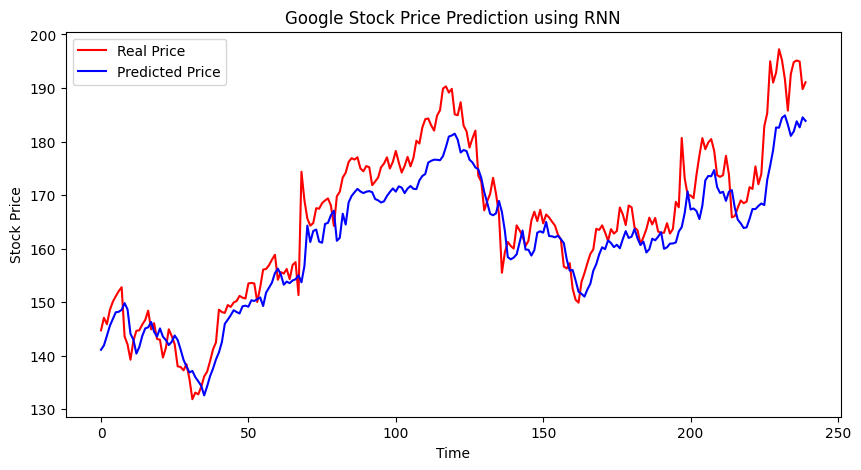

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, SimpleRNN

# -------------------------------
# 1. Load Dataset
# -------------------------------
df = pd.read_csv("/content/Google_Stock_Price.csv")

# Clean and extract Open column
data = pd.to_numeric(df['Open'], errors='coerce').dropna().values
data = data.reshape(-1, 1)

# -------------------------------
# 2. Feature Scaling
# -------------------------------
scaler = MinMaxScaler(feature_range=(0, 1))
data_scaled = scaler.fit_transform(data)

# -------------------------------
# 3. Create Time Series Dataset
# -------------------------------
def create_dataset(dataset, time_step=60):
    X, y = [], []
    for i in range(time_step, len(dataset)):
        X.append(dataset[i-time_step:i, 0])
        y.append(dataset[i, 0])
    return np.array(X), np.array(y)

X, y = create_dataset(data_scaled)

# Reshape for RNN input
X = X.reshape(X.shape[0], X.shape[1], 1)

# -------------------------------
# 4. Train-Test Split
# -------------------------------
train_size = int(len(X) * 0.8)

X_train = X[:train_size]
X_test = X[train_size:]
y_train = y[:train_size]
y_test = y[train_size:]

# -------------------------------
# 5. Build RNN Model
# -------------------------------
model = Sequential()

model.add(SimpleRNN(50, return_sequences=True, input_shape=(60, 1)))
model.add(SimpleRNN(50))
model.add(Dense(1))

model.compile(optimizer='adam', loss='mean_squared_error')

model.summary()

# -------------------------------
# 6. Train Model
# -------------------------------
model.fit(X_train, y_train, epochs=20, batch_size=32)

# -------------------------------
# 7. Prediction
# -------------------------------
predicted = model.predict(X_test)

# Convert back to original scale
predicted = scaler.inverse_transform(predicted.reshape(-1, 1))
real = scaler.inverse_transform(y_test.reshape(-1, 1))

# -------------------------------
# 8. Visualization
# -------------------------------
plt.figure(figsize=(10,5))
plt.plot(real, color='red', label='Real Price')
plt.plot(predicted, color='blue', label='Predicted Price')

plt.title("Google Stock Price Prediction using RNN")
plt.xlabel("Time")
plt.ylabel("Stock Price")
plt.legend()
plt.show()